# 06 — Imbalance Handling

## Objective

The target variable is highly imbalanced, with Fatal accidents representing
a very small proportion of the dataset compared with Other Injury and
Serious Injury accidents.

The baseline Logistic Regression model showed strong performance for the
majority class but poor detection of minority classes, particularly Fatal
accidents.

This notebook investigates whether imbalance-handling techniques can improve
minority-class detection and macro-averaged performance.

The baseline model from Notebook 05 is retained as the reference point.

### Experiments

1. Class-weighted Logistic Regression
2. Oversampling-based Logistic Regression

The test set will remain completely untouched throughout the experiments.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd

from scipy import sparse

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

## 2. Load Preprocessed Training and Testing Data

The preprocessing performed in Notebook 03 and the feature selection performed
in Notebook 04 are reused.

The same Information Gain-selected feature representation used by the
baseline model will be retained so that the imbalance-handling experiments
are directly comparable with the baseline.

In [2]:
X_train = sparse.load_npz("../data/X_train_final.npz")
X_test = sparse.load_npz("../data/X_test_final.npz")

y_train = np.load("../data/y_train_encoded.npy")
y_test = np.load("../data/y_test_encoded.npy")

feature_names = pd.read_csv(
    "../data/final_feature_names.csv"
)["feature_name"].tolist()

selected_features = pd.read_csv(
    "../data/selected_features_ig.csv"
)

In [3]:
print("Training matrix:", X_train.shape)
print("Testing matrix :", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)

Training matrix: (160278, 361)
Testing matrix : (40070, 361)
Training target: (160278,)
Testing target : (40070,)


## 3. Examine Class Distribution

The training data is inspected to quantify the imbalance before applying any
imbalance-handling technique.

In [4]:
class_names = {
    0: "Fatal",
    1: "Other Injury",
    2: "Serious Injury"
}

train_counts = pd.Series(y_train).value_counts().sort_index()

train_distribution = pd.DataFrame({
    "Class": [class_names[i] for i in train_counts.index],
    "Count": train_counts.values,
    "Percentage": (train_counts.values / len(y_train) * 100)
})

train_distribution

,Class,Count,Percentage
0,Fatal,2682,1.673343
1,Other Injury,99953,62.362271
2,Serious Injury,57643,35.964387


## 4. Class-Weighted Logistic Regression

The baseline Logistic Regression model was trained without any
imbalance-handling mechanism. Because the target classes are highly
imbalanced, a class-weighted version is trained next.

The `balanced` class-weighting strategy automatically assigns larger
weights to minority classes and lower weights to majority classes based
on their frequencies in the training data.

Unlike oversampling methods, class weighting does not create or duplicate
training observations. The original training data remains unchanged.

In [5]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for class_id, weight in class_weight_dict.items():
    print(f"{class_names[class_id]}: {weight:.4f}")

Class weights:
Fatal: 19.9202
Other Injury: 0.5345
Serious Injury: 0.9268


## Apply Information Gain Feature Selection

The Information Gain-selected feature set from Notebook 04 is reused so that
the imbalance-handling experiments use the same feature representation as
the baseline Logistic Regression model.

The 26 selected original features correspond to 136 encoded model features
after one-hot encoding.

In [7]:
# Convert to CSR format for reliable column slicing
X_train_csr = X_train.tocsr()
X_test_csr = X_test.tocsr()

# Load the selected original features
selected_original_features = (
    selected_features["original_feature"]
    .tolist()
)

print("Selected original features:", len(selected_original_features))
print(selected_original_features)

Selected original features: 26
['POLICE_ATTEND', 'DCA_CODE', 'DRIVER', 'LONGITUDE', 'ROAD_ROUTE_1', 'PASSENGERVEHICLE', 'NO_OF_VEHICLES', 'VICGRID_Y', 'LATITUDE', 'VICGRID_X', 'MOTORCYCLIST', 'DCA_CODE_DESCRIPTION', 'ACCIDENT_TYPE', 'PEDESTRIAN', 'YOUNG_DRIVER_18_25', 'RUN_OFFROAD', 'DEG_URBAN_NAME', 'MOTORCYCLE', 'SPEED_ZONE', 'OLD_DRIVER_75_AND_OVER', 'TOTAL_PERSONS', 'OLD_PED_65_AND_OVER', 'FEMALES', 'BICYCLIST', 'MALES', 'ROAD_NAME_FREQ']


In [8]:
selected_encoded_indices = []

for feature in selected_original_features:
    for i, encoded_name in enumerate(feature_names):
        if (
            encoded_name == feature
            or encoded_name.startswith(feature + "_")
        ):
            selected_encoded_indices.append(i)

# Remove duplicates while preserving order
selected_encoded_indices = list(dict.fromkeys(selected_encoded_indices))

X_train_selected = X_train_csr[:, selected_encoded_indices]
X_test_selected = X_test_csr[:, selected_encoded_indices]

selected_encoded_feature_names = [
    feature_names[i] for i in selected_encoded_indices
]

print("Reduced training matrix:", X_train_selected.shape)
print("Reduced testing matrix :", X_test_selected.shape)
print("Encoded model features :", len(selected_encoded_feature_names))

Reduced training matrix: (160278, 136)
Reduced testing matrix : (40070, 136)
Encoded model features : 136


## 5. Train Class-Weighted Logistic Regression

The class-weighted Logistic Regression model uses the `balanced` class-weighting
strategy to compensate for the unequal class frequencies.

The model uses the same 136 encoded features and training data representation
as the baseline model, allowing a direct comparison with the baseline results.

In [9]:
weighted_lr = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

weighted_lr.fit(X_train_selected, y_train)

print("Class-weighted Logistic Regression training completed.")

Class-weighted Logistic Regression training completed.


## 6. Evaluate Class-Weighted Logistic Regression

The class-weighted model is evaluated on the untouched test set using the
same metrics as the baseline model.

Macro-averaged metrics are emphasized because the target classes are highly
imbalanced, particularly the Fatal class.

In [10]:
# Generate predictions
y_train_pred_weighted = weighted_lr.predict(X_train_selected)
y_test_pred_weighted = weighted_lr.predict(X_test_selected)

# Generate class probabilities for ROC-AUC
y_test_proba_weighted = weighted_lr.predict_proba(X_test_selected)

# Calculate test metrics
weighted_accuracy = accuracy_score(y_test, y_test_pred_weighted)

weighted_precision = precision_score(
    y_test,
    y_test_pred_weighted,
    average="macro",
    zero_division=0
)

weighted_recall = recall_score(
    y_test,
    y_test_pred_weighted,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_test_pred_weighted,
    average="macro",
    zero_division=0
)

weighted_roc_auc = roc_auc_score(
    y_test,
    y_test_proba_weighted,
    multi_class="ovr",
    average="macro"
)

print("CLASS-WEIGHTED LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy       : {weighted_accuracy:.4f}")
print(f"Precision Macro: {weighted_precision:.4f}")
print(f"Recall Macro   : {weighted_recall:.4f}")
print(f"F1 Macro       : {weighted_f1:.4f}")
print(f"ROC-AUC Macro  : {weighted_roc_auc:.4f}")

CLASS-WEIGHTED LOGISTIC REGRESSION
Accuracy       : 0.5485
Precision Macro: 0.4409
Recall Macro   : 0.5874
F1 Macro       : 0.4184
ROC-AUC Macro  : 0.7336


In [11]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_weighted,
        target_names=["Fatal", "Other Injury", "Serious Injury"],
        zero_division=0
    )
)

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.06      0.72      0.12       670
  Other Injury       0.78      0.62      0.69     24989
Serious Injury       0.48      0.42      0.45     14411

      accuracy                           0.55     40070
     macro avg       0.44      0.59      0.42     40070
  weighted avg       0.66      0.55      0.59     40070



In [12]:
weighted_results = pd.DataFrame({
    "Model": ["Class-Weighted Logistic Regression"],
    "Accuracy": [weighted_accuracy],
    "Precision_Macro": [weighted_precision],
    "Recall_Macro": [weighted_recall],
    "F1_Macro": [weighted_f1],
    "ROC_AUC_Macro": [weighted_roc_auc]
})

weighted_results

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,ROC_AUC_Macro
0,Class-Weighted Logistic Regression,0.548515,0.440868,0.587445,0.418435,0.733576


## 7. Random Oversampling

Random oversampling is applied to the training data to increase the
representation of minority classes.

The test set remains completely untouched.

Random oversampling is used instead of conventional SMOTE because the
current feature representation contains one-hot encoded categorical
variables. Random oversampling preserves the original encoded feature
values and does not create interpolated categorical values.

In [13]:
from imblearn.over_sampling import RandomOverSampler

In [14]:
oversampler = RandomOverSampler(
    random_state=42
)

X_train_over, y_train_over = oversampler.fit_resample(
    X_train_selected,
    y_train
)

print("Original training shape :", X_train_selected.shape)
print("Oversampled training shape:", X_train_over.shape)

print("\nClass distribution after oversampling:")
print(pd.Series(y_train_over).value_counts().sort_index())

Original training shape : (160278, 136)
Oversampled training shape: (299859, 136)

Class distribution after oversampling:
0    99953
1    99953
2    99953
Name: count, dtype: int64


## 8. Train Logistic Regression on Oversampled Data

A Logistic Regression model is trained using the oversampled training data.

The model configuration remains the same as the baseline model so that the
effect of oversampling can be evaluated independently.

The original test set is used for evaluation without any oversampling.

In [15]:
oversampled_lr = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    random_state=42
)

oversampled_lr.fit(X_train_over, y_train_over)

print("Oversampled Logistic Regression training completed.")

## 9. Evaluate Oversampled Logistic Regression

The Logistic Regression model trained on the oversampled training data is
evaluated using the untouched test set.

The same evaluation metrics used for the baseline and class-weighted models
are reported for direct comparison.

In [16]:
# Generate predictions
y_test_pred_over = oversampled_lr.predict(X_test_selected)
y_test_proba_over = oversampled_lr.predict_proba(X_test_selected)

# Calculate test metrics
over_accuracy = accuracy_score(
    y_test,
    y_test_pred_over
)

over_precision = precision_score(
    y_test,
    y_test_pred_over,
    average="macro",
    zero_division=0
)

over_recall = recall_score(
    y_test,
    y_test_pred_over,
    average="macro",
    zero_division=0
)

over_f1 = f1_score(
    y_test,
    y_test_pred_over,
    average="macro",
    zero_division=0
)

over_roc_auc = roc_auc_score(
    y_test,
    y_test_proba_over,
    multi_class="ovr",
    average="macro"
)

print("OVERSAMPLED LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy       : {over_accuracy:.4f}")
print(f"Precision Macro: {over_precision:.4f}")
print(f"Recall Macro   : {over_recall:.4f}")
print(f"F1 Macro       : {over_f1:.4f}")
print(f"ROC-AUC Macro  : {over_roc_auc:.4f}")

OVERSAMPLED LOGISTIC REGRESSION
Accuracy       : 0.5475
Precision Macro: 0.4401
Recall Macro   : 0.5842
F1 Macro       : 0.4173
ROC-AUC Macro  : 0.7331


In [17]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_over,
        target_names=[
            "Fatal",
            "Other Injury",
            "Serious Injury"
        ],
        zero_division=0
    )
)

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.06      0.71      0.12       670
  Other Injury       0.78      0.61      0.69     24989
Serious Injury       0.47      0.42      0.45     14411

      accuracy                           0.55     40070
     macro avg       0.44      0.58      0.42     40070
  weighted avg       0.66      0.55      0.59     40070



## 10. Confusion Matrix — Oversampled Model

The confusion matrix is used to examine the class-wise prediction behavior
of the Logistic Regression model trained on the oversampled training data.

In [18]:
cm_over = confusion_matrix(
    y_test,
    y_test_pred_over
)

print("Confusion Matrix:")
print(cm_over)

Confusion Matrix:
[[  479    25   166]
 [ 3040 15363  6586]
 [ 4081  4235  6095]]


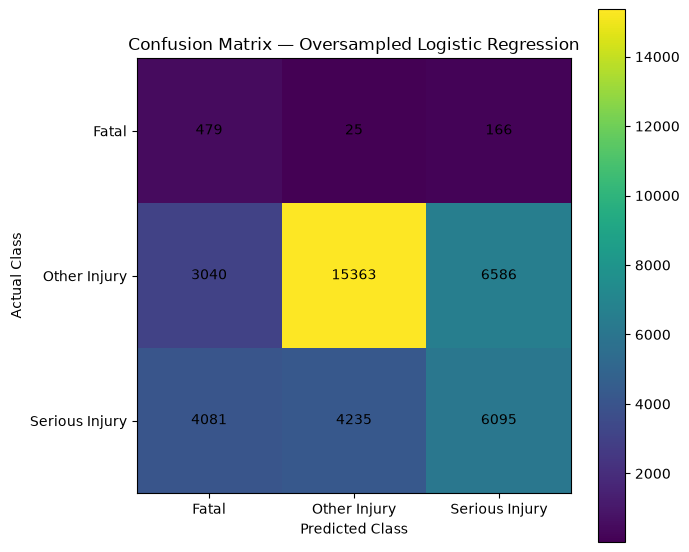

In [19]:
plt.figure(figsize=(7, 6))

plt.imshow(cm_over)

plt.title("Confusion Matrix — Oversampled Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1, 2],
    ["Fatal", "Other Injury", "Serious Injury"]
)

plt.yticks(
    [0, 1, 2],
    ["Fatal", "Other Injury", "Serious Injury"]
)

for i in range(cm_over.shape[0]):
    for j in range(cm_over.shape[1]):
        plt.text(
            j,
            i,
            cm_over[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

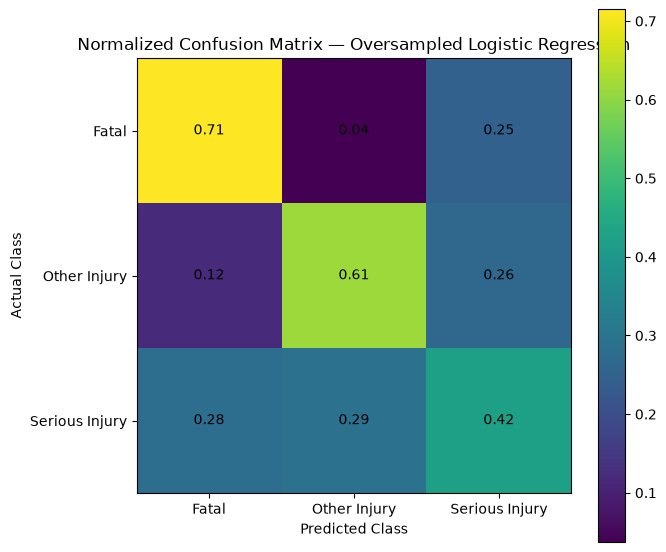

In [20]:
cm_over_normalized = confusion_matrix(
    y_test,
    y_test_pred_over,
    normalize="true"
)

plt.figure(figsize=(7, 6))

plt.imshow(cm_over_normalized)

plt.title("Normalized Confusion Matrix — Oversampled Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1, 2],
    ["Fatal", "Other Injury", "Serious Injury"]
)

plt.yticks(
    [0, 1, 2],
    ["Fatal", "Other Injury", "Serious Injury"]
)

for i in range(cm_over_normalized.shape[0]):
    for j in range(cm_over_normalized.shape[1]):
        plt.text(
            j,
            i,
            f"{cm_over_normalized[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## 11. Comparison of Imbalance-Handling Approaches

The baseline and two imbalance-handling approaches are compared using
accuracy, macro-averaged precision, recall, F1-score, and ROC-AUC.

Macro-averaged metrics are emphasized because the target variable is highly
imbalanced.

In [21]:
comparison_results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Class-Weighted Logistic Regression",
        "Oversampled Logistic Regression"
    ],
    "Accuracy": [
        0.667432,
        weighted_accuracy,
        over_accuracy
    ],
    "Precision_Macro": [
        0.527138,
        weighted_precision,
        over_precision
    ],
    "Recall_Macro": [
        0.414588,
        weighted_recall,
        over_recall
    ],
    "F1_Macro": [
        0.415015,
        weighted_f1,
        over_f1
    ],
    "ROC_AUC_Macro": [
        0.766439,
        weighted_roc_auc,
        over_roc_auc
    ]
})

comparison_results

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,ROC_AUC_Macro
0,Baseline Logistic Regression,0.667432,0.527138,0.414588,0.415015,0.766439
1,Class-Weighted Logistic Regression,0.548515,0.440868,0.587445,0.418435,0.733576
2,Oversampled Logistic Regression,0.547467,0.440121,0.584219,0.417262,0.733146


## 12. Imbalance Handling — Results and Discussion

The baseline Logistic Regression model achieved a test Macro F1-score of
0.4150 but showed very poor detection of Fatal accidents.

Class weighting substantially improved minority-class detection. In
particular, Fatal recall increased from approximately 0.9% in the baseline
model to 72%. However, this improvement came with a substantial reduction
in overall accuracy, from 66.74% to 54.85%. The Macro F1-score increased
only slightly, from 0.4150 to 0.4184.

Random oversampling produced a similar behavior. Fatal recall increased to
approximately 71%, and Macro Recall increased substantially compared with
the baseline. However, the test Macro F1-score was 0.4173, which was only
slightly higher than the baseline and lower than the class-weighted model.

Therefore, neither imbalance-handling approach produced a substantial
improvement in overall Macro F1-score for the Logistic Regression model.
Class weighting produced the best Macro F1-score among the imbalance
experiments, while both approaches substantially improved Fatal-class
recall.

These results suggest that the limitations are not caused by class
imbalance alone. More flexible nonlinear models will therefore be
investigated in the subsequent modeling stage.